In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import *
import math
import csv
import pandas as pd
from scipy.optimize import minimize
import string
from scipy.signal import find_peaks
from scipy import integrate
from pathlib import Path
import re
from scipy.integrate import odeint
from scipy.optimize import curve_fit
import scipy.interpolate as interp
from matplotlib.ticker import MultipleLocator
from numpy import linalg as lin
from scipy.interpolate import interp1d
import os
from scipy.optimize import brentq
from numpy.polynomial import Polynomial
import scipy.special as sp
import matplotlib.colors as mcolors
import random
from matplotlib.patches import Patch
from datetime import datetime

white = "#FFFFFF"
pastel_red = "#E6412E"
pastel_orange = "#FFBB6E"
pastel_yellow = "#FFF5BE"
pastel_green = "#B2EAB3"
light_blue = '#AED6F1' 
dark_blue = '#2874A6' 
dark_gray = '#2C3E50'
pastel_purple = '#AF7AC5'
black = '#000000'
  

In [123]:
# Convert hex to RGB
def hex_to_rgb(hex_color):
    return np.array(mcolors.to_rgb(hex_color))

# Time to make a nice looking graph
def RyansGraph(x, y=1, plot_names=None, Title="", xaxis="xaxis", yaxis="yaxis", 
               xfit=None, yfit=None, errorx=None, errory=None, ylower=None, yupper=None,
               colour_point=None, cmap_point=None,
               mainfit='Trend of best fit', outerfit='Outer fit', error_name="Error",
               keypoints=None, keypointsName="",
               size=1, type="Scalar",
               Dualx=None, Dualy=None,
               Dualxfit=None, Dualyfit=None, Dualerrorx=None, Dualerrory=None, Dualylower=None, Dualyupper=None,
               Dualmainfit='Dual Trend of best fit', Dualouterfit='Dual Outer fit',
               colours = [[hex_to_rgb(light_blue), hex_to_rgb(pastel_purple)], [hex_to_rgb(pastel_orange), hex_to_rgb(dark_blue)]], opac = 0.2,
               # BB84
               is_imag = False,
               colour_key = None
               ):
    
    if is_imag == False:
        plt.style.use('seaborn-v0_8-white')
        fig, ax = plt.subplots(figsize=(6*size, 4*size))
        colour_order = ['Black', pastel_red, pastel_purple]

        # Title and labels
        ax.set_title(Title, fontsize=15*size)
        ax.set_xlabel(xaxis, fontsize=12*size)
        ax.set_ylabel(yaxis, fontsize=12*size)
        ax.tick_params(axis='both', labelsize=12*size)

        # The points themselves
        if errorx is not None or errory is not None:
            ax.errorbar(x, y,
                xerr=None if errorx is None else np.abs(errorx),
                yerr=None if errory is None else np.abs(errory),
                fmt='none', ecolor= pastel_red, capsize=2, label=error_name
            )
        
        shape = x.shape
        if len(shape) == 1:
            _, cols = shape[0], 1
        else:
            _, cols = shape

        for i in np.arange(cols):
            print("BOOP")

        for i in np.arange(cols):
            if type == "Log":
                ax.plot(x , y)
                plt.yscale('log')
            elif type == "Scalar":
                plt.scatter(x, y, marker='x', color = 'Black')
                if xfit is not None:
                    plt.plot(xfit,yfit, color = colours[0][0], linewidth=2.5, alpha = 0.7, label=mainfit)
                if ylower is not None:
                    plt.plot(xfit,ylower, color = colours[0][0], linewidth=2.5, alpha = 0.7, linestyle="--", label=outerfit)
                if yupper is not None:
                    plt.plot(xfit,yupper, color = colours[0][0], linewidth=2.5, alpha = 0.7, linestyle="--")
                if keypoints is not None:
                    plt.scatter(keypoints[:,0], keypoints[:,1], marker='x', color=colours[0][1], label=keypointsName)
            elif type == "fit":
                plt.plot(x, y, color = 'Black')
            elif type == 'Dual':
                # Scatter points
                plt.scatter(x, y, marker='x', color='Black')
                plt.scatter(Dualx, Dualy, marker='x', color='Navy')
                
                # Fits
                if xfit is not None:
                    plt.plot(xfit, yfit, color=colours[0][0], linewidth=2.5, alpha=0.7, label=mainfit)

                if Dualxfit is not None:
                    for i in range(Dualyfit.shape[0]):
                        if isinstance(Dualmainfit, list):
                            label = Dualmainfit[i]
                        else:
                            label = Dualmainfit if i == 0 else f"{Dualmainfit} ({i})"

                        plt.plot(Dualxfit, Dualyfit[i],
                                color=colours[1][i % len(colours[1])],
                                linewidth=2.5,
                                alpha=0.7,
                                label=label)
                if ylower is not None:
                    plt.plot(xfit, ylower, color=colours[0][0], linewidth=2.5, alpha=0.7, linestyle='--', label=outerfit)
                if yupper is not None:
                    plt.plot(xfit, yupper, color=colours[0][0], linewidth=2.5, alpha=0.7, linestyle='--')
                
                if Dualylower is not None:
                    plt.plot(Dualxfit, Dualylower, color=colours[1][0], linewidth=2.5, alpha=0.7, linestyle='--', label=Dualouterfit)
                if Dualyupper is not None:
                    plt.plot(Dualxfit, Dualyupper, color=colours[1][0], linewidth=2.5, alpha=0.7, linestyle='--')

    if type == "BB84" :
        # print(x)
        delta = np.abs(x[:, 0] - x[:, 1])
        # delta = np.nan_to_num(delta, nan=0)  # treat NaN as max difference
        opacity = (1 - delta) * (1 - opac) + opac

        N = len(x)
        n_cols = x.shape[1]
        img = np.zeros((n_cols, N, 4))

        for i in range(N):
            # Row 0
            for j in range(n_cols // 2):

                # Row 0
                if np.isnan(x[i, 2*j]):
                    img[2*j, i, :] = [1.0, 1.0, 1.0, 1.0]
                else:
                    img[2*j, i, :3] = colours[j][0] if x[i, 2*j] == 0 else colours[j][1]
                    img[2*j, i, 3]  = opacity[i]

                # Row 1
                if np.isnan(x[i, 2*j+1]):
                    img[2*j+1, i, :] = [1.0, 1.0, 1.0, 1.0]
                else:
                    img[2*j+1, i, :3] = colours[j][0] if x[i, 2*j+1] == 0 else colours[j][1]
                    img[2*j+1, i, 3]  = opacity[i]

        # plotting

        fig, ax = plt.subplots(figsize=(10, 0.25*n_cols))

        ax.imshow(img, aspect='auto')

        # --- Black line under 4th row ---
        ax.axhline(y=3.5, color='black', linewidth=2)

        # --- Row labels ---
        labels = plot_names

        if colour_key is not None:
            # Create custom legend
            legend_elements = []
            for idx, name in enumerate(colour_key):
                legend_elements.append(Patch(facecolor=colours[idx//2][idx%2], edgecolor='black', label=name))
            plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=12*size)

        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels)

        # Optional: move labels closer
        ax.tick_params(axis='y', length=0)

        # Remove x-axis
        ax.set_xticks([])

        plt.show()
        return


    # Make everything look nice
    ax.legend(facecolor='white', framealpha=1, edgecolor='black', fontsize=12*size)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.tick_params(axis='both', colors='black', direction='out', length=4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    # Make sure everything is displayed
    plt.tight_layout()
    plt.show()

In [62]:
def reset():
    print ("Resetting...")
    N2 = []
    df = pd.read_csv('7-04-Ryan expiriment\joule_thomson_data_2_N2.csv', skiprows=1)
    N2 = df.iloc[:, ].to_numpy() 
    
    for i in np.arange(len(N2[:, 12] )):
        if np.isnan(N2[i, 12]):
            N2[i, 12] = N2[i-1, 12]

    CO2 = []
    df = pd.read_csv('7-04-Ryan expiriment\joule_thomson_data_1_CO2.csv', skiprows=1)
    CO2 = df.iloc[:, ].to_numpy()

    for i in np.arange(len(CO2[:, 12] )):
        if np.isnan(CO2[i, 12]):
            CO2[i, 12] = CO2[i-1, 12]

    return N2, CO2
N2, CO2 = reset()

Resetting...


In [4]:
def exp_model(t, A, k, C):
    return A * np.exp(k * t) + C

def linear_model(x, m, b):
    return m * x + b

In [135]:
#Theory calculations


# Van der Waals constants for [N2, CO2]
a_list = [1.370e-1, 3.59e-1]   # Pa·m^6/mol^2
b_list = [3.91e-5, 4.27e-5]    # m^3/mol
Cp_list = [29.1, 37.1]         # J/(mol K)

P = 1e5
R = 8.314
T = 300

mu_bar_list = []

for a, b, Cp in zip(a_list, b_list, Cp_list):

    # Cubic coefficients
    coeffs = [
        P,
        -(R*T + P*b),
        a,
        -a*b
    ]

    roots = np.roots(coeffs)

    # Physical root
    v = np.max(roots[np.isreal(roots)].real)

    # Thermal expansion coefficient
    alpha = (R / (v - b)) / ((R*T) / (v - b)**2 - (2*a) / v**3)

    # Joule–Thomson coefficient
    mu = (1 / Cp) * (T * alpha - v)

    mu_bar_list.append(mu * 1e5)
    print(v)
print(v)
print(mu_bar_list)


0.024926224019704266
0.024840425948602734
0.024840425948602734
[np.float64(0.24302816474922945), np.float64(0.665854372835586)]


In [140]:
# Now using the Peng–Robinson equation of state

a = 0.364
b = 4.27e-5
Cp = 37.1
R = 8.314
T = 300
P = 1e5

# CO2 critical properties
Tc = 304.2
Pc = 7.38e6
omega = 0.225

# Peng-Robinson parameters
kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
alpha = (1 + kappa*(1 - np.sqrt(T/Tc)))**2

a = 0.45724 * (R**2 * Tc**2) / Pc
b = 0.07780 * (R * Tc) / Pc

print("a =", a*alpha)
print("b =", b)

# Solve cubic for v
coeffs = [
    P,
    -(R*T - P*b),
    a*alpha - 2*P*b**2 - 2*R*T*b,
    -(a*alpha*b - P*b**3 - R*T*b**2)
]

roots = np.roots(coeffs)
v = np.max(roots[np.isreal(roots)].real)

dT = 1e-3

def volume(T):
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    alpha = (1 + kappa*(1 - np.sqrt(T/Tc)))**2
    a = 0.45724 * (R**2 * Tc**2) / Pc
    b = 0.07780 * (R * Tc) / Pc

    coeffs = [
        P,
        -(R*T - P*b),
        a*alpha - 2*P*b**2 - 2*R*T*b,
        -(a*alpha*b - P*b**3 - R*T*b**2)
    ]

    roots = np.roots(coeffs)
    v = np.max(roots[np.isreal(roots)].real)
    return v

v1 = volume(T)
v2 = volume(T + dT)

alpha_num = (v2 - v1) / dT

Cp = 37.1  # CO2

mu_PR = (1/Cp) * (T * alpha_num - v1) * 1e5

print("v1 =", v1, "m^3/mol")
print("mu =", mu_PR, "K/bar")

a = 0.40019886485849004
b = 2.6661984097560973e-05
v1 = 0.02480783265991252 m^3/mol
mu = 1.1041212028285114 K/bar


Resetting...
BOOP
0.14285714285714285
0.003822687993915844
BOOP
0.14285714285714285
0.010593336704730644
BOOP
0.16666666666666666
0.003819792298169983
BOOP
0.125
2.2970850838325823
BOOP
0.14285714285714285
0.0001510918517188648
BOOP
0.14285714285714285
0.0013530248220515553
BOOP
0.14285714285714285
0.0002039829289435552
BOOP
0.125
0.00011460722628590962
BOOP
0.14285714285714285
0.000338905075877878
BOOP
0.14285714285714285
3.399562310368073e-05
BOOP
0.14285714285714285
373453.69347443426
BOOP


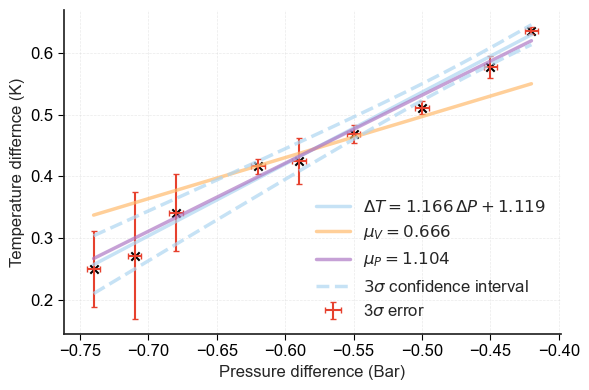

Fitting params: [1.16587952 1.11941847]
[[0.0032548  0.0015511 ]
 [0.0015511  0.00075772]]
mu = 1.166 ± 0.171 K/bar


In [ ]:
N2, CO2 = reset()

subject = "CO2"

if subject == "N2":
    data = N2
    theory = [mu_bar_list[0]]
    filter = 100
elif subject == "CO2":
    data = CO2
    theory = [mu_bar_list[1], mu_PR]
    filter = 10

# Ok so lets strart with finding the true value

mask = data[:, 1] >= 0.26
data = data[mask]


data[:, 0] = np.array([
    datetime.strptime(t, "%H:%M:%S").hour * 3600 +
    datetime.strptime(t, "%H:%M:%S").minute * 60 +
    datetime.strptime(t, "%H:%M:%S").second
    for t in data[:, 0]
])
data[:, 0] = data[:, 0] - data[0, 0]
# print(data[:, 0])
# sc = plt.scatter(data[:, 0], data[:, 11], c=data[:, 1], cmap='viridis')
# plt.colorbar(sc, label="Pressure")
# plt.show()

# plt.scatter(data[0:20, 0], data[0:20, 11], c=data[0:20, 1], cmap='viridis')

# Ok next thing to work on is getting the assympotic value of temperature difference
pressures = np.unique(data[:, 1])

fits = {}

for p in pressures:
    mask = data[:, 1] == p
    
    t = data[mask, 0].astype(float)
    y = data[mask, 11].astype(float)
    sigma_y = data[mask, 12].astype(float)
    
    if len(y) < 3:
        continue # skip
    
    C0 = y[-1]
    A0 = y[0] - C0
    k0 = -0.01
    
    bounds = ([-np.inf, -1, 0.5 * y[-1]], [ np.inf,  0, 2.0 * y[-1]])
    
    try:
        popt, pcov = curve_fit(
            exp_model,
            t, y,
            p0=(A0, k0, C0),
            sigma=sigma_y,
            bounds=bounds,
            absolute_sigma=True, 
            maxfev=5000)
        
    except RuntimeError:
        print(f"Fit failed for p={p}")
        continue
    
    fits[p] = {
        "A": popt[0],
        "k": popt[1],
        "C": popt[2],
        "cov": pcov}
    
    
    t_fit = np.linspace(np.min(t), np.max(t), 200)
    # plt.plot(t_fit, exp_model(t_fit, *popt), label=f"p={p}")
    # print("BOOP")
    # print(1/len(y))
    # print(pcov[2, 2])

# plt.show()


pressures = np.array(list(fits.keys()))
delta_T = np.array([fits[p]["C"] for p in pressures])

# A constraint
mask = np.abs(np.array([fits[p]["A"] for p in pressures])) >= filter

pressures_f = pressures[mask] - 1
delta_T_f = delta_T[mask]

sigma_C = np.array([np.sqrt(fits[p]["cov"][2,2]) for p in pressures])
sigma_C_f = sigma_C[mask]
popt, pcov = curve_fit(linear_model, pressures_f, delta_T_f,
          sigma=sigma_C_f,
          absolute_sigma=True)
m, b = popt

t_fit = np.linspace(np.min(pressures_f), np.max(pressures_f), 200)
y_fit = m * t_fit + b

unc_fit = 3 * np.sqrt(t_fit**2 * pcov[0, 0] + pcov[1, 1] + 2 * t_fit * pcov[0, 1])

upper_fit = m * t_fit + b + unc_fit
lower_fit = m * t_fit + b - unc_fit

if subject == "N2":
    theory_fit = theory * t_fit + t_fit[len(t_fit)//2] * (m - theory) + b
    RyansGraph(pressures_f, delta_T_f, xaxis="Pressure difference (Bar)", yaxis="Temperature differnce (K)",
           xfit=t_fit, yfit=y_fit, ylower=lower_fit, yupper=upper_fit,
           errorx=0.005, errory=sigma_C_f, error_name=rf"3$\sigma$ error",
           mainfit=rf"$\Delta T = {m:.3f}\,\Delta P + {b:.3f}$", outerfit=r"$3\sigma$ confidence interval",
           type="Dual",
           Dualxfit=t_fit, Dualyfit=theory_fit, Dualmainfit=rf"$Theory: \mu_V = {theory[0]:.3f}$")
elif subject == "CO2":
    t0 = t_fit[len(t_fit)//2]
    theory_fit_v = np.outer(theory, (t_fit - t0)) + (m * t0 + b)
    RyansGraph(pressures_f, delta_T_f, xaxis="Pressure difference (Bar)", yaxis="Temperature differnce (K)",
           xfit=t_fit, yfit=y_fit, ylower=lower_fit, yupper=upper_fit,
           errorx=0.005, errory=sigma_C_f, error_name=rf"3$\sigma$ error",
           mainfit=rf"$\Delta T = {m:.3f}\,\Delta P + {b:.3f}$", outerfit=r"$3\sigma$ confidence interval",
           type="Dual",
           colours = [[hex_to_rgb(light_blue), hex_to_rgb(pastel_purple)], [hex_to_rgb(pastel_orange), hex_to_rgb(pastel_purple)]], opac = 0.2,
           Dualxfit=t_fit, Dualyfit=theory_fit_v, Dualmainfit=[rf"$\mu_V = {theory[0]:.3f}$",rf"$\mu_P = {theory[1]:.3f}$" ])
print(f"Fitting params: {popt}")
print(pcov)
print(f"mu = {m:.3f} ± {3*np.sqrt(pcov[0,0]):.3f} K/bar")
# print(fits)

BOOP


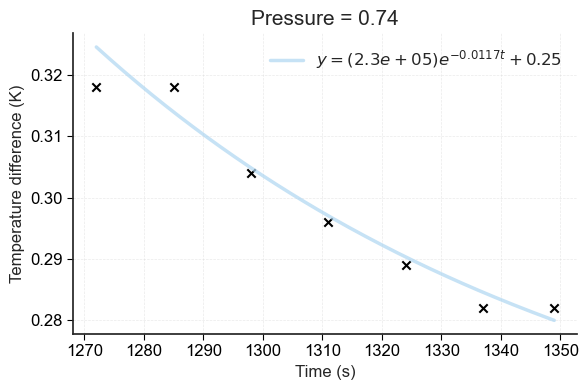

BOOP


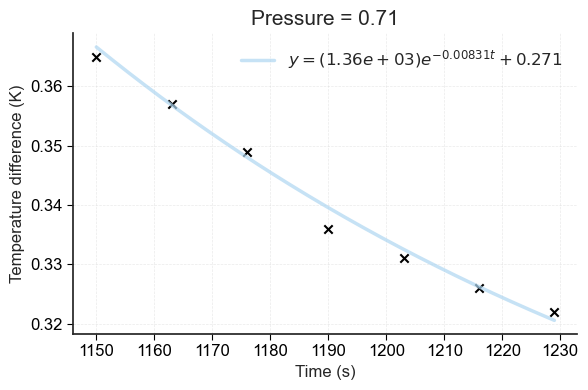

BOOP


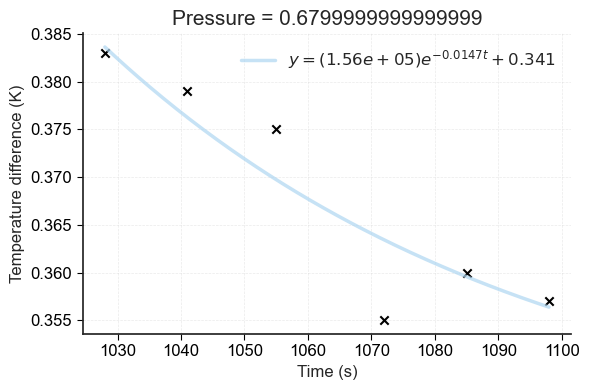

BOOP


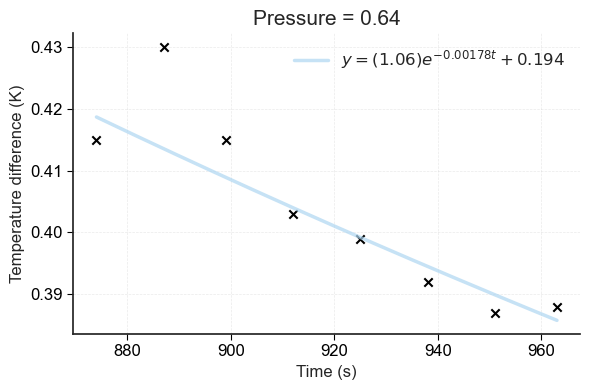

BOOP


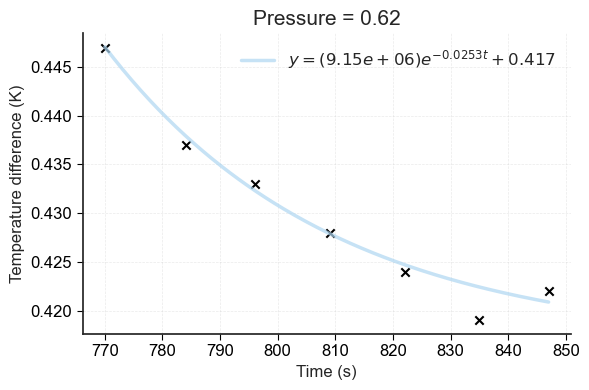

BOOP


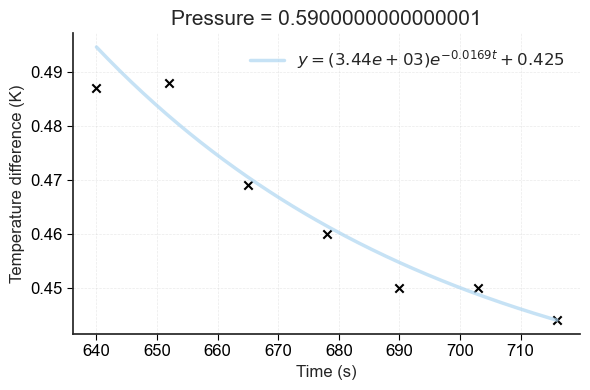

BOOP


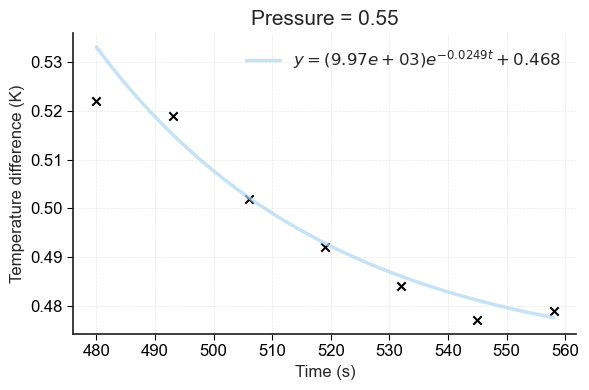

BOOP


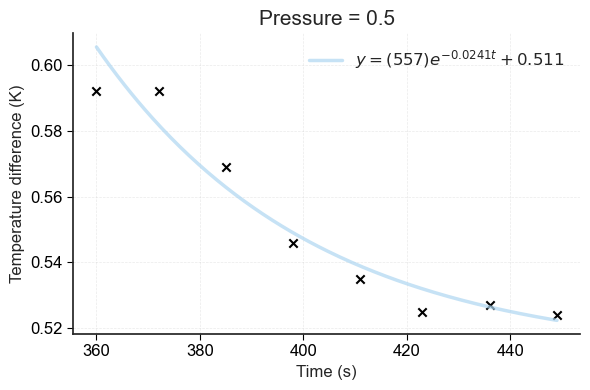

BOOP


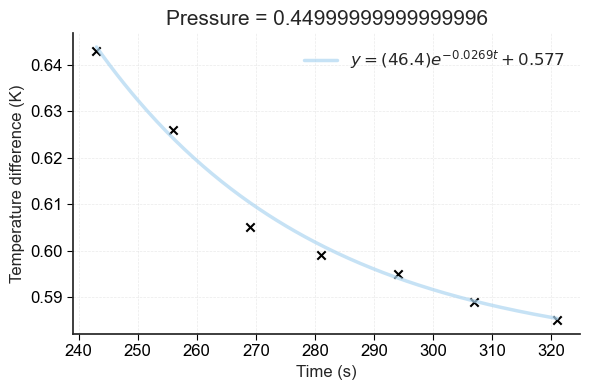

BOOP


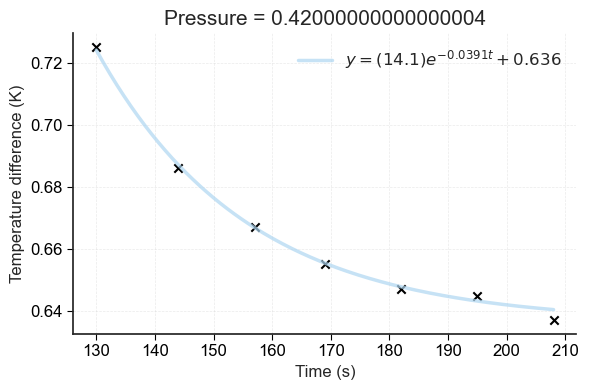

BOOP


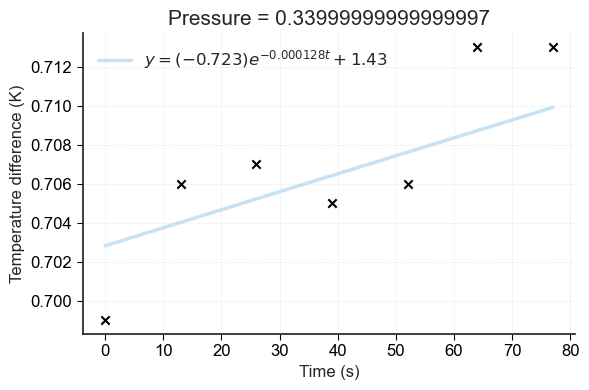

In [98]:
for p, res in fits.items():
    mask = data[:, 1] == p
    
    t = data[mask, 0].astype(float)
    # t = t - t[0]
    y = data[mask, 11].astype(float)
    
    A = res["A"]
    k = res["k"]
    C = res["C"]
    
    t_fit = np.linspace(np.min(t), np.max(t), 200)
    y_fit = exp_model(t_fit, A, k, C)
    
    # Format parameter text into legend instead
    mainfit = rf"$y = ({A:.3g}) e^{{{k:.3g} t}} + {C:.3g}$"
    
    RyansGraph(
        t, y,
        Title=f"Pressure = {1-p}",
        xaxis="Time (s)",
        yaxis="Temperature difference (K)",
        xfit=t_fit,
        yfit=y_fit,
        mainfit=mainfit,
        outerfit=""  # not using bounds here
    )